## PageRank Algorithm

In [12]:
import numpy as np
from scipy import linalg as la

# PageRank matrix
M = np.array([
    [0,     0,     1/2,   0    ],
    [1/3,   0,     0,     1/2  ],
    [1/3,   1/2,   0,     1/2  ],
    [1/3,   1/2,   1/2,   0    ]
], dtype=float)

n = M.shape[0]

print("Column sums:", M.sum(axis=0))  # should all be 1


# ---------- Eigenvector Method ----------
eigvals, eigvecs = la.eig(M)
idx = np.argmin(np.abs(eigvals - 1))   # eigenvalue closest to 1
v = eigvecs[:, idx].real               # take real part

if np.all(v < 0):                      # make positive if needed
    v = -v

pagerank_eig = v / v.sum()             # normalize
print("Eigen PageRank:")
print(pagerank_eig)


# ---------- Power Iteration ----------
v = np.ones(n) / n   # start uniform
dif = 1e-8

for k in range(1000):
    v_new = M @ v
    v_new = v_new / v_new.sum()
    if np.linalg.norm(v_new - v) < dif:
        print("Power iteration steps:", k+1)
        v = v_new
        break
    v = v_new

pagerank_power = v
print("Power Iteration PageRank:")
print(pagerank_power)
print(sum(pagerank_power))


# ---------- Find Top Page ----------
best = np.argmax(pagerank_power)
print("Highest page:", best + 1)
print("Score:", pagerank_power[best])


Column sums: [1. 1. 1. 1.]
Eigen PageRank:
[0.15789474 0.21052632 0.31578947 0.31578947]
Power iteration steps: 15
Power Iteration PageRank:
[0.15789474 0.21052632 0.31578947 0.31578947]
1.0
Highest page: 3
Score: 0.31578947374541266


## Dimensionality Reduction via PCA

Covariance matrix:
 [[1.02608749 0.11769063]
 [0.11769063 1.08134929]]
PC1: [0.62106317 0.78376051]


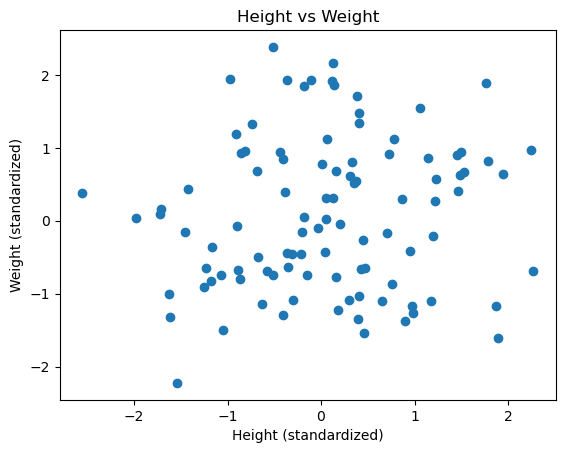

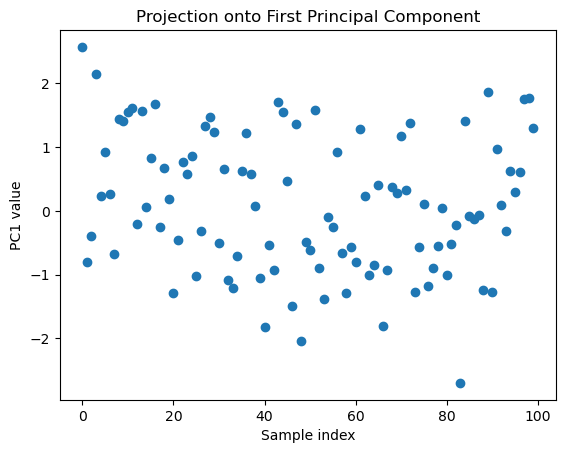

In [29]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import linalg as la

data = np.loadtxt("data.csv", delimiter=",", skiprows=1)

# covariance of height weight
cov = np.cov(data, rowvar=False)
print("Covariance matrix:\n", cov)

# eigenvalues and eigenvectors
vals, vecs = la.eigh(cov)

# sort in decreasing order
idx = np.argsort(vals)[::-1]
vals = vals[idx]
vecs = vecs[:, idx]

# first principal component
pc1 = vecs[:, 0]
print("PC1:", pc1)

# project data onto PC1
proj = data @ pc1

# scatter plot of height vs weight
plt.scatter(data[:, 0], data[:, 1])
plt.xlabel("Height (standardized)")
plt.ylabel("Weight (standardized)")
plt.title("Height vs Weight")
plt.show()

# scatter plot of PC1 projection
plt.scatter(range(len(proj)), proj)
plt.xlabel("Sample index")
plt.ylabel("PC1 value")
plt.title("Projection onto First Principal Component")
plt.show()


## Linear Regression via Least Squares

In [35]:
import numpy as np
from scipy import linalg as la

X = np.array([
    [2100, 3, 20],
    [2500, 4, 15],
    [1800, 2, 30],
    [2200, 3, 25]
], dtype=float)

y = np.array([460, 540, 330, 400], dtype=float)

# xb = y
beta, _, _, _ = la.lstsq(X, y)

print("Beta")
print(beta)

# Predict the price for a new house
x_new = np.array([2400, 3, 20], dtype=float)
pred_price = x_new @ beta

print("Predicted price for the new house:")
print(pred_price, "thousand dollars")

# Direct solution
XtX = X.T @ X
Xty = X.T @ y
beta_direct = la.solve(XtX, Xty)

print("Coefficients")
print(beta_direct)


Beta
[    3.2875 -1628.75     -77.75  ]
Predicted price for the new house:
1448.7500000000234 thousand dollars
Coefficients
[    3.2875     -1628.75000001   -77.75      ]


## Gradient Descent for Minimizing Loss Function

Iteration: 88
Final loss: 3.7048797673733135e-06


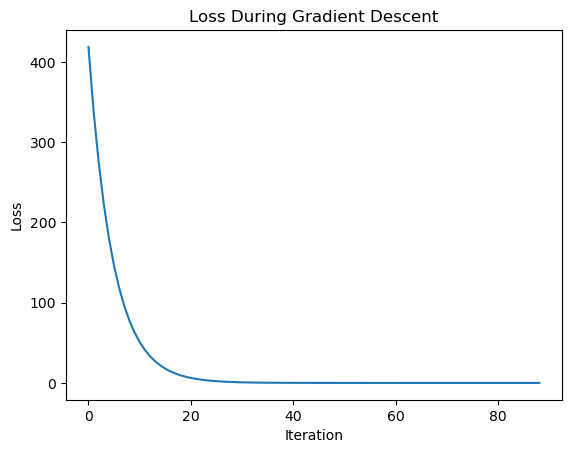

In [34]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)

# Create matrices
X = np.random.rand(100, 50)
A = np.random.rand(100, 50)

# Loss function
def loss(X, A):
    return 0.5 * np.sum((X - A)**2)

learning_rate = 0.1
tol = 1e-6
max_iter = 1000

loss_history = []
old_loss = loss(X, A)
loss_history.append(old_loss)

for k in range(max_iter):
    grad = X - A                  # gradient of 1/2 ||X - A||^2
    X = X - learning_rate * grad  # gradient descent update

    new_loss = loss(X, A)
    loss_history.append(new_loss)

    if abs(new_loss - old_loss) < tol:
        print("Iteration:", k + 1)
        break

    old_loss = new_loss

print("Final loss:", new_loss)

plt.plot(loss_history)
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.title("Loss During Gradient Descent")
plt.show()